# Homework Submission - Stage 10b: Time Series and Classification

This completion uses the official starter's seeded regime-and-jump series. Features are past-only, the split is chronological, preprocessing is inside sklearn Pipelines, and results are judged against naive baselines.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, precision_score, recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
np.random.seed(7)
ROOT = Path.cwd()
FIGURES = ROOT / 'reports' / 'images'
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Generate a regime-changing return series

In [2]:
n = 500
dates = pd.bdate_range('2021-01-01', periods=n)
mu = np.where(np.arange(n) < n // 2, 0.0003, -0.0001)
sigma = np.where(np.arange(n) < n // 2, 0.01, 0.015)
eps = np.random.normal(mu, sigma)
jumps = np.zeros(n)
jump_days = np.random.choice(np.arange(20, n - 20), size=5, replace=False)
jumps[jump_days] = np.random.normal(0, 0.05, size=len(jump_days))
returns = eps + jumps
price = 100 * np.exp(np.cumsum(returns))

df = pd.DataFrame({'price': price}, index=dates)
df.index.name = 'date'
df['ret'] = df['price'].pct_change()
df['log_ret'] = np.log1p(df['ret'])
display(df.head())

,price,ret,log_ret
date,,,
2021-01-01,101.735412,NaN,NaN
2021-01-04,101.292875,-0.004350,-0.004359
2021-01-05,101.356527,0.000628,0.000628
2021-01-06,101.800950,0.004385,0.004375
2021-01-07,101.031283,-0.007561,-0.007589


## 2. Engineer past-only features and next-step targets

Every rolling statistic ends with `shift(1)`, so the row at time `t` uses observations through `t-1`. The target is return at `t+1`; the final row is dropped because that outcome is unknown.

In [3]:
df['lag_1'] = df['ret'].shift(1)
df['lag_2'] = df['ret'].shift(2)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)
df['roll_vol_20'] = df['ret'].rolling(20).std().shift(1)
df['momentum_5'] = df['price'].pct_change(5).shift(1)
prior_mean_20 = df['ret'].rolling(20).mean().shift(1)
prior_std_20 = df['ret'].rolling(20).std().shift(1)
df['zscore_20'] = (df['lag_1'] - prior_mean_20) / prior_std_20

df['y_next_ret'] = df['ret'].shift(-1)
df['y_up'] = (df['y_next_ret'] > 0).astype(int)
features = ['lag_1', 'lag_2', 'roll_mean_5', 'roll_vol_20', 'momentum_5', 'zscore_20']
df_features = df.dropna(subset=features + ['y_next_ret']).copy()
assert df_features.index.is_monotonic_increasing
assert not df_features[features + ['y_next_ret']].isna().any().any()
display(df_features[features + ['y_next_ret', 'y_up']].head())

,lag_1,lag_2,roll_mean_5,roll_vol_20,momentum_5,zscore_20,y_next_ret,y_up
date,,,,,,,,
2021-02-01,0.016949,-0.014854,0.002509,0.008455,0.012347,2.090596,-0.003565,0
2021-02-02,0.001845,0.016949,0.001706,0.008429,0.008303,0.268365,0.020804,1
2021-02-03,-0.003565,0.001845,0.000685,0.008453,0.003163,-0.347615,-0.000154,0
2021-02-04,0.020804,-0.003565,0.004236,0.009675,0.020920,2.130277,-0.014106,0
2021-02-05,-0.000154,0.020804,0.007176,0.009502,0.036154,-0.075624,-0.003745,0


## 3. Chronological split

In [4]:
cut = int(len(df_features) * 0.80)
train = df_features.iloc[:cut]
test = df_features.iloc[cut:]
assert train.index.max() < test.index.min()

X_train, X_test = train[features], test[features]
y_train_reg, y_test_reg = train['y_next_ret'], test['y_next_ret']
y_train_clf, y_test_clf = train['y_up'], test['y_up']
print('Train:', train.index.min().date(), 'to', train.index.max().date(), len(train), 'rows')
print('Test: ', test.index.min().date(), 'to', test.index.max().date(), len(test), 'rows')

Train: 2021-02-01 to 2022-07-19 382 rows
Test:  2022-07-20 to 2022-11-30 96 rows


## 4. Forecasting pipeline and baseline comparison

,mae,rmse
pipeline,0.011680,0.014611
zero_return_baseline,0.011668,0.014599


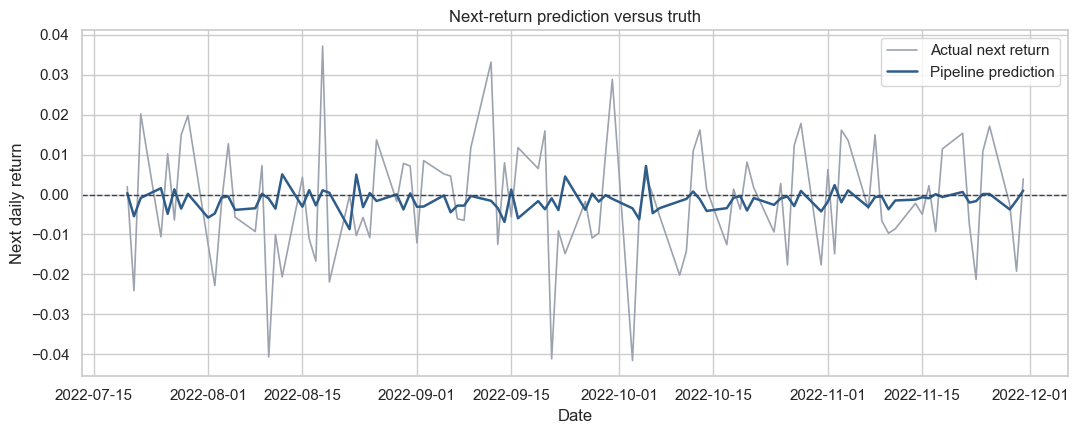

In [5]:
forecasting_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_regression', LinearRegression()),
])
forecasting_pipeline.fit(X_train, y_train_reg)
return_prediction = forecasting_pipeline.predict(X_test)
zero_prediction = np.zeros(len(y_test_reg))

forecasting_metrics = pd.DataFrame({
    'pipeline': {
        'mae': mean_absolute_error(y_test_reg, return_prediction),
        'rmse': mean_squared_error(y_test_reg, return_prediction) ** 0.5,
    },
    'zero_return_baseline': {
        'mae': mean_absolute_error(y_test_reg, zero_prediction),
        'rmse': mean_squared_error(y_test_reg, zero_prediction) ** 0.5,
    },
}).T
display(forecasting_metrics)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(test.index, y_test_reg, color='#9CA3AF', label='Actual next return', linewidth=1.2)
ax.plot(test.index, return_prediction, color='#2F5D8A', label='Pipeline prediction', linewidth=1.8)
ax.axhline(0, color='#374151', linestyle='--', linewidth=1)
ax.set(title='Next-return prediction versus truth', xlabel='Date', ylabel='Next daily return')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'next_return_prediction.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Direction-classification pipeline

,test_metric
accuracy,0.531250
precision,0.450000
recall,0.209302
f1,0.285714
majority_class_accuracy,0.552083


              precision    recall  f1-score   support

           0       0.55      0.79      0.65        53
           1       0.45      0.21      0.29        43

    accuracy                           0.53        96
   macro avg       0.50      0.50      0.47        96
weighted avg       0.51      0.53      0.49        96



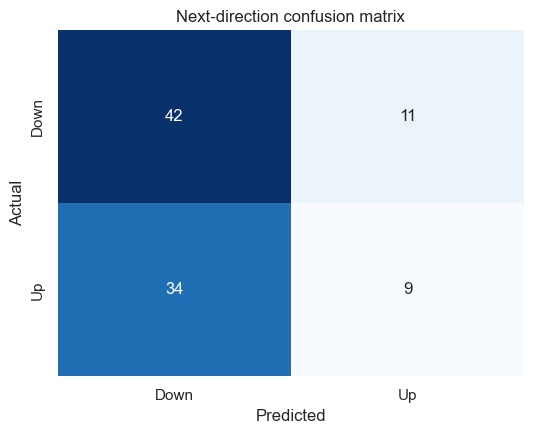

In [6]:
classification_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(max_iter=1000, random_state=7)),
])
classification_pipeline.fit(X_train, y_train_clf)
direction_prediction = classification_pipeline.predict(X_test)
direction_probability = classification_pipeline.predict_proba(X_test)[:, 1]

classification_metrics = pd.Series({
    'accuracy': accuracy_score(y_test_clf, direction_prediction),
    'precision': precision_score(y_test_clf, direction_prediction, zero_division=0),
    'recall': recall_score(y_test_clf, direction_prediction, zero_division=0),
    'f1': f1_score(y_test_clf, direction_prediction, zero_division=0),
    'majority_class_accuracy': max(y_test_clf.mean(), 1 - y_test_clf.mean()),
}, name='test_metric')
display(classification_metrics.to_frame())
print(classification_report(y_test_clf, direction_prediction, zero_division=0))

cm = confusion_matrix(y_test_clf, direction_prediction, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
ax.set(title='Next-direction confusion matrix', xlabel='Predicted', ylabel='Actual')
fig.tight_layout()
fig.savefig(FIGURES / 'direction_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Interpretation and risk assessment

- **What worked technically:** all six predictors use only past information; the most recent 20% is held out; scaling is fit only through each Pipeline's training call; both tracks produce the required metrics and plots.
- **What failed substantively:** the return forecaster does not beat a zero-return baseline on MAE, and direction accuracy is below the test set's majority-class benchmark. Up-day recall is especially weak. These are negative but valid baseline results.
- **Why:** the generator has changing mean/volatility and rare jumps but little intentional next-day predictability. Scaling and a linear/logistic model cannot manufacture signal from noisy lag features.
- **Where assumptions break:** regime shifts make coefficients nonstationary; rolling windows mix regimes; transaction costs would further hurt weak forecasts; jump risk is poorly represented by average error metrics.

**Next step:** retain the naive benchmarks, use expanding-window cross-validation, test regime indicators and calendar/volatility features, calibrate classification probabilities, and evaluate after costs. Do not tune on this test period or describe the synthetic result as a trading strategy.